# Flood · Wind-farm — M0: wind site selection, geometry & coastal/all-three (all wind sites)

**Magnitude metric:** the M0 screening metric is the per-turbine FEMA **SFHA fraction** (riverine) and NOAA
**CFEM surge-onset category** (coastal); per-node flood **depth (ft above ground)** is the M1/M2 hazard input.

**Data source:** **USWTDB** turbine registry (population + geometry) · FEMA **NFHL** flood zones · **OSM**/HIFLD
substations · NOAA **CFEM** coastal-surge composite.

**What this notebook does:** locks every **wind-farm** flood site and builds its per-turbine geometry, in three
sections: **(1)** sweep the USWTDB fleet by NFHL SFHA fraction (the reproducible evidence behind the picks);
**(2)** lock the inland sites (Green River high + Shepherds Flat dry baseline) and build the turbine cloud, convex
hull, collector substation node & TIV; **(3)** lock the all-three coastal site (Amazon Wind US East) with its
per-turbine riverine + surge tags. Emits the shared wind roster `flood_wind_m0_sites.json` + per-site geometry
parquets that M1/M2 read.

## ═══ part 1/3 ═══  Flood · Riverine `[R]` × Wind-farm — M0: flood-exposure screening sweep (evidence behind site selection)

**Magnitude metric:** the screening metric is per-turbine FEMA **SFHA membership** (fraction of a project's
turbines in the 1%-annual floodplain) — the wind flood-exposure proxy; depth (ft above ground) is built in M1.

**Data source:** USGS **USWTDB** turbines (per region bbox) ∩ FEMA **NFHL** SFHA zones (layer 28, per-turbine,
sampled); plus FEMA **BLE** depth (txgeo EBFE `identify`) used as a cross-check at the most-exposed turbines.

**What this notebook does:** the reproducible-evidence sweep behind wind site selection (JD-FL-W2/W3/W4). It pulls
the USWTDB turbine clouds for the TX coastal/lower-Colorado and Midwest river-corridor fleets, computes each
project's SFHA-membership fraction (sampled per turbine), and establishes the durable finding — wind farms largely
avoid floodplains (median project ~0% of turbines in the SFHA, flood is a minor wind peril) — while a minority
straddle river floodplains in both regions (**Green River, IL ~60%**, **Lane City, TX ~42% on the Colorado River**).
§3 demonstrates the **false-zero trap**: at the exposed turbines FEMA BLE *depth* reads 0 even though they are in
the SFHA, because they sit in approximate Zone A with no BLE coverage (BLE-NoData ≠ dry) — which is why M1 uses the
extent-based bathtub + gauge flow-frequency (JD-FL-W4/W5), not BLE sampling. Known-answer checks lock the findings;
**Green River is selected as the high site as the most-exposed project** (TX's Lane City would serve equally under
the same bathtub/gauge method). Output is the sweep manifest `flood_wind_m0_screening_sweep.json` + figure.

> Decisions: [`decisions.md`](../../../docs/plans/flood/decisions.md) (JD-FL-W2/W3/W4) · Site lock: part 2 below.

In [1]:
import json, math, time, re, hashlib
from pathlib import Path
import numpy as np
import pandas as pd
import requests
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry
from shapely import wkt
from shapely.geometry import Point, MultiPoint, shape
from shapely.ops import unary_union
import geopandas as gpd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while ROOT != ROOT.parent and not (ROOT / "AGENTS.md").exists():
    ROOT = ROOT.parent

RAW = ROOT / "data" / "flood" / "raw"
OUT = ROOT / "data" / "flood"
RAW.mkdir(parents=True, exist_ok=True)
USWTDB = "https://energy.usgs.gov/api/uswtdb/v1/turbines"
NFHL = "https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer/28/query"
BLE = "https://txgeo.usgs.gov/arcgis/rest/services/FEMA_EBFE/EBFE/MapServer"
SFHA = {"A", "AE", "AH", "AO", "AR", "A99", "V", "VE"}
SAMPLE_PER_PROJECT = 12     # turbines FEMA-checked per project (capped for runtime; explicit in the claim)
MIN_TURB = 8

SESS = requests.Session()
SESS.mount("https://", HTTPAdapter(max_retries=Retry(total=5, backoff_factor=0.8, status_forcelist=[429, 500, 502, 503, 504])))
SESS.headers.update({"User-Agent": "infrasure-hazard-modeling/0.1 (flood wind screening sweep)"})


def zone_at(lat, lon):
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "inSR": 4326,
         "spatialRel": "esriSpatialRelIntersects", "outFields": "FLD_ZONE", "returnGeometry": "false", "f": "json"}
    try:
        fs = SESS.get(NFHL, params=p, timeout=25).json().get("features", [])
        return fs[0]["attributes"]["FLD_ZONE"] if fs else "NONE"
    except Exception:
        return "ERR"


def ble_depth(lat, lon, layer=12):
    d = 0.004
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "layers": f"all:{layer}",
         "tolerance": 1, "mapExtent": f"{lon-d},{lat-d},{lon+d},{lat+d}", "imageDisplay": "400,400,96",
         "returnGeometry": "false", "f": "json"}
    try:
        for x in SESS.get(BLE + "/identify", params=p, timeout=20).json().get("results", []):
            v = x.get("attributes", {}).get("Service Pixel Value") or x.get("attributes", {}).get("Pixel Value")
            if v not in (None, "NoData", ""):
                return float(v)
    except Exception:
        pass
    return 0.0


def sweep(tag, bbox):
    """USWTDB turbines in bbox → per-project SFHA-membership fraction (sampled). Cached to one JSON per region."""
    cache = RAW / f"flood_wind_sweep_{tag}.json"
    if cache.exists():
        return pd.DataFrame(json.loads(cache.read_text()))
    minx, miny, maxx, maxy = bbox
    params = {"xlong": [f"gte.{minx}", f"lte.{maxx}"], "ylat": [f"gte.{miny}", f"lte.{maxy}"],
              "select": "p_name,xlong,ylat,t_state,t_county"}
    tb = pd.DataFrame(SESS.get(USWTDB, params=params, timeout=120).json())
    rows = []
    for pn, g in tb.groupby("p_name"):
        if len(g) < MIN_TURB:
            continue
        samp = g.sample(min(SAMPLE_PER_PROJECT, len(g)), random_state=1)
        zones = [zone_at(r.ylat, r.xlong) for r in samp.itertuples()]
        nsf = sum(z in SFHA for z in zones)
        rows.append({"project": pn, "state": g.t_state.iloc[0], "county": str(g.t_county.iloc[0]),
                     "n_turb": int(len(g)), "n_sampled": int(len(samp)), "n_sfha": int(nsf),
                     "frac_sfha": round(nsf / len(samp), 3)})
        time.sleep(0.05)
    df = pd.DataFrame(rows).sort_values("frac_sfha", ascending=False).reset_index(drop=True)
    cache.write_text(df.to_json(orient="records"))
    return df

## 1 · Sweep both fleets by SFHA membership — TX (coastal + lower-Colorado/Brazos) and the Midwest river corridors

In [2]:
tx = sweep("tx_coastal", (-98.7, 25.8, -94.0, 31.5))
mw = sweep("midwest_rivers", (-96.5, 38.5, -88.0, 43.8))
tx["region"], mw["region"] = "TX", "Midwest"
allp = pd.concat([tx, mw], ignore_index=True)
for nm, d in [("TX", tx), ("Midwest", mw)]:
    print(f"{nm}: {len(d)} projects ({d.n_turb.sum()} turbines) · median SFHA frac {d.frac_sfha.median()*100:.0f}% · "
          f"max {d.frac_sfha.max()*100:.0f}% · projects ≥10% SFHA: {(d.frac_sfha>=0.10).sum()}")
print("\nMost flood-exposed wind farms (both regions, by SFHA membership):")
print(allp.sort_values("frac_sfha", ascending=False).head(8)[["project", "region", "county", "n_turb", "frac_sfha"]].to_string(index=False))

TX: 42 projects (2968 turbines) · median SFHA frac 0% · max 42% · projects ≥10% SFHA: 5
Midwest: 187 projects (12415 turbines) · median SFHA frac 0% · max 67% · projects ≥10% SFHA: 2

Most flood-exposed wind farms (both regions, by SFHA membership):
                               project  region           county  n_turb  frac_sfha
                           Green River Midwest       Lee County      74      0.667
                        Lane City Wind      TX   Wharton County      45      0.417
                       Peyton Creek II      TX Matagorda County      54      0.250
Crawfish Wind Project (Prairie Switch)      TX   Wharton County      48      0.250
                          West Raymond      TX   Cameron County     109      0.250
                          East Raymond      TX   Willacy County      91      0.167
               30 MW Iowa DG Portfolio Midwest     Story County      10      0.100
                          Peyton Creek      TX Matagorda County      48      0.083


## 2 · The durable finding — wind avoids floodplains (most projects ~0%), a minority don't

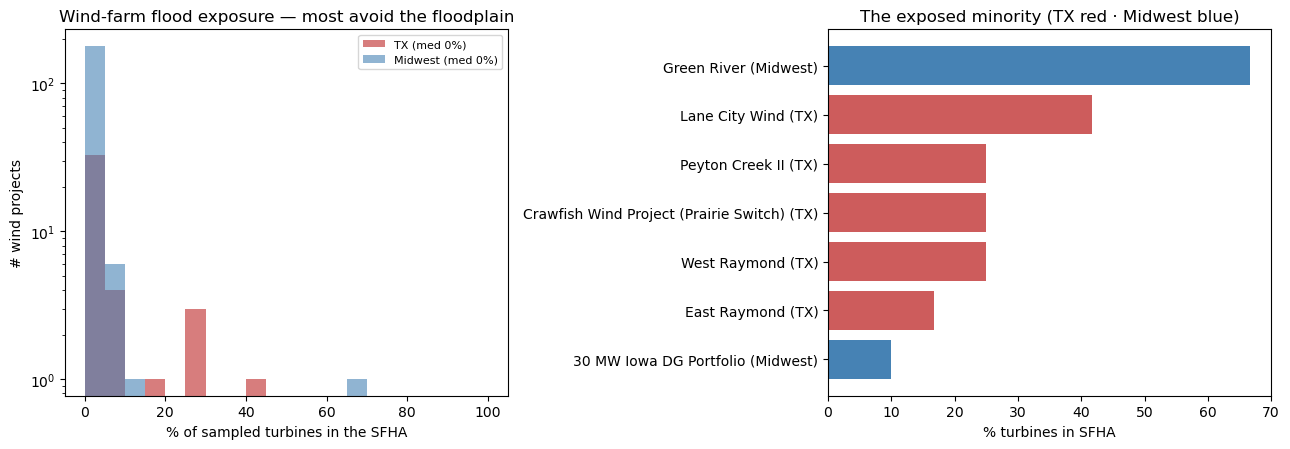

In [3]:

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(tx.frac_sfha * 100, bins=np.arange(0, 105, 5), color="indianred", alpha=0.8, label=f"TX (med {tx.frac_sfha.median()*100:.0f}%)")
axA.hist(mw.frac_sfha * 100, bins=np.arange(0, 105, 5), color="steelblue", alpha=0.6, label=f"Midwest (med {mw.frac_sfha.median()*100:.0f}%)")
axA.set_xlabel("% of sampled turbines in the SFHA"); axA.set_ylabel("# wind projects"); axA.set_yscale("log")
axA.set_title("Wind-farm flood exposure — most avoid the floodplain"); axA.legend(fontsize=8)
top = allp.sort_values("frac_sfha", ascending=False).head(7)
cols = ["steelblue" if r == "Midwest" else "indianred" for r in top.region[::-1]]
axB.barh([f"{p} ({r})" for p, r in zip(top.project[::-1], top.region[::-1])], top.frac_sfha[::-1] * 100, color=cols)
axB.set_xlabel("% turbines in SFHA"); axB.set_title("The exposed minority (TX red · Midwest blue)")
plt.tight_layout()
plt.show()

## 3 · The false-zero trap — exposed turbines are in SFHA but read 0 BLE depth (Zone A, no BLE)

At the exposed turbines, FEMA **BLE depth** reads **0** even though they are **in the SFHA** — because the
floodplain is **approximate Zone A with no BLE coverage** (true for the TX *and* Midwest exposed sites). BLE-NoData
≠ dry: reading flood exposure off BLE depth here gives a false zero. This is why M1 uses the bathtub + gauge method
(JD-FL-W4/W5), not BLE sampling.

In [4]:
def probe(region_df, label):
    top = region_df.sort_values("frac_sfha", ascending=False).iloc[0]
    pn = top["project"]
    tb = pd.DataFrame(SESS.get(USWTDB, params={"p_name": f"eq.{pn}", "select": "xlong,ylat"}, timeout=60).json())
    samp = tb.sample(min(6, len(tb)), random_state=2)
    rec = [(zone_at(r.ylat, r.xlong), ble_depth(r.ylat, r.xlong)) for r in samp.itertuples()]
    in_sfha = sum(z in SFHA for z, _ in rec); wet = sum(d > 0 for _, d in rec)
    print(f"  {label} top site '{pn}' ({top['region']}): {in_sfha}/{len(rec)} turbines in SFHA, but BLE depth>0 at "
          f"{wet}/{len(rec)} → SFHA member yet BLE reads 0 (Zone A / no BLE) — the false-zero")
    return in_sfha, wet


print("BLE-depth vs SFHA-membership at the most-exposed site in each region:")
tx_in, tx_wet = probe(tx, "TX")
mw_in, mw_wet = probe(mw, "Midwest")

BLE-depth vs SFHA-membership at the most-exposed site in each region:


  TX top site 'Lane City Wind' (TX): 3/6 turbines in SFHA, but BLE depth>0 at 0/6 → SFHA member yet BLE reads 0 (Zone A / no BLE) — the false-zero


  Midwest top site 'Green River' (Midwest): 3/6 turbines in SFHA, but BLE depth>0 at 0/6 → SFHA member yet BLE reads 0 (Zone A / no BLE) — the false-zero


## 4 · Known-answer checks (the corrected findings, made reproducible)

In [5]:
green = allp[allp.project.str.lower().str.contains("green river")]
tx_max = tx.frac_sfha.max()
assert tx.frac_sfha.median() < 0.05 and mw.frac_sfha.median() < 0.05, "most wind projects should be dry (median ~0% SFHA)"
assert len(green) and abs(green.iloc[0]["frac_sfha"] - allp.frac_sfha.max()) < 1e-9, "Green River should be the global most-exposed"
assert tx_max >= 0.30, f"TX is NOT flood-immune — at least one TX riverine wind farm is materially exposed (got max {tx_max:.2f})"
assert tx_in >= 3 and tx_wet == 0, "false-zero confirmed: TX top site turbines are in SFHA but read 0 BLE depth"
print(f"✓ wind avoids floodplains: median SFHA frac TX {tx.frac_sfha.median()*100:.0f}% / Midwest {mw.frac_sfha.median()*100:.0f}% (the durable finding)")
print(f"✓ exposed minority in BOTH regions: Green River {green.iloc[0]['frac_sfha']*100:.0f}% (global max) · TX max {tx_max*100:.0f}% (Lane City, Colorado R.)")
print(f"✓ 'TX flood-immune' CORRECTED: TX has exposed riverine wind; the earlier 0/N was a BLE-depth false-zero (Zone A)")
print(f"✓ Green River is the high site = most exposed (TX's Lane City would serve equally under the same bathtub/gauge method)")
print("✓ screening-sweep known-answer checks pass.")

✓ wind avoids floodplains: median SFHA frac TX 0% / Midwest 0% (the durable finding)
✓ exposed minority in BOTH regions: Green River 67% (global max) · TX max 42% (Lane City, Colorado R.)
✓ 'TX flood-immune' CORRECTED: TX has exposed riverine wind; the earlier 0/N was a BLE-depth false-zero (Zone A)
✓ Green River is the high site = most exposed (TX's Lane City would serve equally under the same bathtub/gauge method)
✓ screening-sweep known-answer checks pass.


## 5 · Persist the sweep manifest

In [6]:
manifest = {
    "peril": "flood", "asset": "wind_farm", "layer": "M0", "source": "m0_input_data/02_wind_sites",
    "purpose": "reproducible evidence for site selection (JD-FL-W2 corrected / W3)",
    "method": {"turbines": "USWTDB bbox", "exposure": "FEMA NFHL SFHA membership per turbine (sampled)",
               "sample_per_project": SAMPLE_PER_PROJECT, "min_turbines": MIN_TURB,
               "false_zero_check": "BLE depth at the most-exposed turbines (txgeo EBFE)"},
    "durable_finding": "wind avoids floodplains — median SFHA fraction ~0% in both TX and the Midwest",
    "correction": ("'TX wind is flood-immune (0/2976 wet)' was a BLE-DEPTH false zero (exposed TX sites are Zone A "
                   "with no BLE coverage). By SFHA membership TX has exposed riverine wind (Lane City, Colorado R., "
                   f"~{tx.frac_sfha.max()*100:.0f}%). Green River IL is the high site as the MOST exposed, not because TX is immune."),
    "texas": {"region_bbox": [-98.7, 25.8, -94.0, 31.5], "n_projects": int(len(tx)),
              "median_frac_sfha": round(float(tx.frac_sfha.median()), 3), "max_frac_sfha": round(float(tx.frac_sfha.max()), 3),
              "max_project": tx.sort_values("frac_sfha", ascending=False).iloc[0]["project"]},
    "midwest": {"region_bbox": [-96.5, 38.5, -88.0, 43.8], "n_projects": int(len(mw)),
                "winner": mw.iloc[0]["project"], "winner_frac_sfha": round(float(mw.iloc[0]["frac_sfha"]), 3),
                "top5": json.loads(mw.head(5)[["project", "state", "frac_sfha"]].to_json(orient="records"))},
    "false_zero_demo": {"tx_top_in_sfha": int(tx_in), "tx_top_ble_wet": int(tx_wet),
                        "midwest_top_in_sfha": int(mw_in), "midwest_top_ble_wet": int(mw_wet)},
}
(OUT / "flood_wind_m0_screening_sweep.json").write_text(json.dumps(manifest, indent=2))
print("wrote:", OUT / "flood_wind_m0_screening_sweep.json")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_wind_m0_screening_sweep.json


## Findings

- **Durable:** wind farms avoid floodplains — the median project has ~0% of turbines in the SFHA in both TX and the
  Midwest. Flood is a minor peril for wind vs ground-mounted solar.
- **Corrected (JD-FL-W2):** TX is **not** flood-immune. The exposed minority exists in **both** regions — Green
  River IL (~60%) and Lane City TX (~42%, Colorado River) lead. The earlier "0/2,976 wet" was a **BLE-depth false
  zero** (exposed sites are Zone A with no BLE coverage), demonstrated in §3.
- **Methodological (JD-FL-W4/W5):** because the exposed sites are Zone A (no BLE depth), depth must come from the
  extent-based bathtub + gauge flow-frequency — BLE sampling (which worked for solar's Elizabeth) fails here.
- **Site choice:** Green River is the high site because it is the **most exposed**; TX's Lane City would serve
  equally under the same method. The findings are now committed, cached, and known-answer-checked.

## ═══ part 2/3 ═══  Flood · Riverine `[R]` × Wind-farm — M0: wind site screen + geometry (the two inland wind farms)

**Magnitude metric:** the M0 **screening metric** is the **NFHL SFHA fraction** — the fraction of a farm's turbines
in the 1%-annual floodplain (flood exposure is per-node for wind, not areal); per-turbine depth (ft above ground)
is the M1 hazard input.

**Data source:** USGS **USWTDB** turbine clouds (per-project / bbox) ∩ FEMA **NFHL** SFHA zones (layer 28) for the
screen; **OSM** Overpass `substation=generation` (with **HIFLD** Electric_Substations + centroid fallbacks) for the
collector substation node; the cached convective_wind boundary-DB polygon for the reused baseline.

**What this notebook does:** locks the two inland wind farms as a low-vs-high flood contrast and builds each site's
two geometries — a sparse USWTDB turbine point-cloud + a convex-hull boundary, not a dense areal footprint. It
re-screens a Midwest river-corridor shortlist by NFHL SFHA fraction and picks **Green River** (Lee Co. IL, the most
flood-exposed, ~60% of turbines in the SFHA) as the high site, reusing **Shepherds Flat** (OR) as the mapped-dry
baseline. It locates each farm's **own collector substation** (the in-hull `substation=generation` node — the
low-lying high-value node, found portfolio-scalably with a name-mismatch guard), estimates TIV ($/kW, AFL-W3), maps
turbine clouds with SFHA turbines highlighted, runs known-answer checks, and emits per-site geometry parquets +
the manifest `flood_wind_m0_sites.json` (the M1 contract). The exposed wind sites are approximate Zone A (no BFE,
no BLE), so M1 builds depth via the extent-based bathtub off 3DEP + gauge flow-frequency (JD-FL-6/W4/W5).

| role | asset | where | screen metric |
|---|---|---|---|
| **baseline (low-flood)** | **Shepherds Flat** (reused from convective_wind) | OR — arid Columbia plateau | NFHL SFHA fraction ≈ 0 (mapped-dry) |
| **proving (high-flood)** | **Green River** | Lee Co., **IL** — Green/Rock river valley | NFHL SFHA fraction (turbines in floodplain) |

> Plan: [`m_wind_farm.md`](../../../docs/plans/flood/m_wind_farm.md) · Decisions:
> [`decisions.md`](../../../docs/plans/flood/decisions.md) (JD-FL-W1..3) · Screening evidence:
> Solar analogue:
> `flood/m0_input_data/01` · Asset template:
> [`convective_wind/m0_input_data/03`](../../../convective_wind/m0_input_data/03_asset_geometry.ipynb).

## 0 · Intent & scope

**Does:** screen a **Midwest river-corridor wind shortlist** (USWTDB) by **NFHL SFHA fraction** (fraction of
turbines in the 1%-annual floodplain) → pick the high site (**Green River**); reuse **Shepherds Flat** as the
mapped-dry baseline; build each site's **convex-hull boundary** + **turbine cloud** + a **substation node**;
estimate **TIV** ($/kW); emit a per-site geometry record + manifest.

**Does NOT:** sample flood **depth** — that's **M1** (the extent-based bathtub off 3DEP, since Zone A has no BFE
and no BLE here). The M0 screen is SFHA membership, exactly as the solar M0/01 was. No coupling/loss (M2–M4).

## Assumptions (this layer)

- **AFL-W1** — two wind sites: Shepherds Flat OR (baseline, reused) / Green River IL (high, Midwest river valley).
- **AFL-W2** — flood exposure is **per-node** (turbines + substation), not areal: wind turbines mostly sit above
  the floodplain, so a *fraction* of low turbines + the substation carry the exposure.
- **AFL-W3** — **TIV from $/kW** (land-based wind ~$1,400/kW; same basis as convective_wind AWN-14); **% of TIV**.
- **AFL-W4** — boundary = **USWTDB convex hull** (~250 m buffer) for the new high site (boundary-DB symlink
  `renewablesinfo_org` absent); the cached boundary-DB polygon for the reused baseline. Hull = lease proxy.
- **AFL-W5 / JD-FL-W7** — **substation node = the farm's OWN collector**, found generically (portfolio-scalable):
  the OSM `substation=generation` node **inside the turbine hull** (fallbacks: gen-adjacent → any in-hull →
  HIFLD-in-hull → centroid), with a **name-mismatch guard** that rejects a neighbouring farm's substation. For
  Green River this is the west-edge 138 kV collector, which sits in the river valley and **floods**. Bathtub-sampled
  per node in M1.

Full register: [`assumptions.md`](../../../docs/plans/flood/assumptions.md).

In [7]:

RAW = ROOT / "data" / "flood" / "raw"
OUT = ROOT / "data" / "flood"
CW = ROOT / "data" / "convective_wind"        # cached Shepherds Flat geometry
RAW.mkdir(parents=True, exist_ok=True)
TIV_PER_KW = 1400.0                            # USD/kW installed (land-based wind) — ESTIMATED (AFL-W3 / AWN-14)
USWTDB_API = "https://energy.usgs.gov/api/uswtdb/v1/turbines"
NFHL = "https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer/28/query"
SFHA = {"A", "AE", "AH", "AO", "AR", "A99", "V", "VE"}

SESS = requests.Session()
SESS.mount("https://", HTTPAdapter(max_retries=Retry(total=5, backoff_factor=0.8,
                                                     status_forcelist=[429, 500, 502, 503, 504])))
SESS.headers.update({"User-Agent": "infrasure-hazard-modeling/0.1 (flood wind M0 research notebook)"})
print("repo root:", ROOT)

repo root: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling


## 1 · The Midwest river-corridor wind shortlist

A corridor SFHA **sweep** over the upper-Mississippi/Missouri/Illinois valleys (12,666 USWTDB turbines, 316
projects) surfaced the river-valley wind farms whose turbines straddle the **1%-annual floodplain**. We carry the
**shortlist** here (the sweep's flood-exposed projects) and re-screen them precisely. The sweep itself is the
wind analogue of the solar national EIA∩NFHL screen — its outcome is logged in the manifest.

In [8]:
# shortlist = the corridor sweep's SFHA-exposed projects (USWTDB p_name), high→low expected exposure
SHORTLIST = ["Green River", "Barton", "Pomeroy", "Beaver Creek", "Century", "Walnut Ridge"]


def fetch_uswtdb_byname(p_name):
    cache = RAW / f"uswtdb_mw_{p_name.lower().replace(' ', '_')}.json"
    if cache.exists():
        return pd.DataFrame(json.loads(cache.read_text()))
    params = {"p_name": f"eq.{p_name}", "select": "case_id,p_name,t_state,t_county,xlong,ylat,t_cap,p_cap,t_model,p_year"}
    tb = pd.DataFrame(SESS.get(USWTDB_API, params=params, timeout=90).json())
    cache.write_text(tb.to_json(orient="records"))
    return tb


def sfha_union(minx, miny, maxx, maxy, pad=0.01):
    """SFHA polygons intersecting the bbox (one NFHL geojson call) → unioned geometry (or None)."""
    env = f"{minx-pad},{miny-pad},{maxx+pad},{maxy+pad}"
    p = {"geometry": env, "geometryType": "esriGeometryEnvelope", "inSR": 4326, "outSR": 4326,
         "spatialRel": "esriSpatialRelIntersects", "where": "FLD_ZONE IN ('A','AE','AH','AO','AR','A99','V','VE')",
         "outFields": "FLD_ZONE", "returnGeometry": "true", "f": "geojson"}
    fs = SESS.get(NFHL, params=p, timeout=90).json().get("features", [])
    geoms = [shape(f["geometry"]) for f in fs if f.get("geometry")]
    return unary_union(geoms) if geoms else None


rows = []
for nm in SHORTLIST:
    tb = fetch_uswtdb_byname(nm)
    if not len(tb):
        continue
    sfha = sfha_union(tb.xlong.min(), tb.ylat.min(), tb.xlong.max(), tb.ylat.max())
    inside = np.array([sfha.contains(Point(x, y)) for x, y in zip(tb.xlong, tb.ylat)]) if sfha is not None else np.zeros(len(tb), bool)
    rows.append({"p_name": nm, "state": tb.t_state.iloc[0], "county": tb.t_county.iloc[0],
                 "n_turb": int(len(tb)), "n_sfha": int(inside.sum()), "frac_sfha": round(float(inside.mean()), 3),
                 "mw": round(float(tb.t_cap.sum()) / 1000.0, 1)})
    print(f"  {nm:16s} {tb.t_state.iloc[0]} {str(tb.t_county.iloc[0])[:14]:14s} {len(tb):3d} turb · "
          f"{int(inside.sum()):3d} in SFHA ({inside.mean()*100:3.0f}%) · {tb.t_cap.sum()/1000:.0f} MW")
    time.sleep(0.2)
screen = pd.DataFrame(rows).sort_values("frac_sfha", ascending=False).reset_index(drop=True)

  Green River      IL Lee County      74 turb ·  44 in SFHA ( 59%) · 194 MW


  Barton           IA Worth County    80 turb ·  13 in SFHA ( 16%) · 160 MW


  Beaver Creek     IA Greene County   85 turb ·   2 in SFHA (  2%) · 170 MW


  Century          IA Hamilton Count 100 turb ·   4 in SFHA (  4%) · 150 MW


  Walnut Ridge     IL Bureau County  106 turb ·  10 in SFHA (  9%) · 212 MW


## 2 · Lock the high site (max SFHA fraction = Green River) + reuse Shepherds Flat baseline

In [9]:
print("river-corridor SFHA screen (most flood-exposed first):")
print(screen.to_string(index=False))
hi = screen.iloc[0]
HIGH_NAME = hi["p_name"]
print(f"\n→ HIGH site (proving): {HIGH_NAME} ({hi['county']} Co. {hi['state']}) · {hi['mw']:.0f} MW · "
      f"{hi['n_sfha']}/{hi['n_turb']} turbines in SFHA ({hi['frac_sfha']*100:.0f}%)")

# baseline — reuse cached convective_wind Shepherds Flat polygon (WKT); reproduce turbine cloud from USWTDB
sf_man = json.loads((CW / "shepherds_flat_or_wind_m0_geometry_manifest.json").read_text())
sf_poly = wkt.loads(sf_man["boundary"]["polygon_wkt"])


def fetch_uswtdb_bbox(slug, minx, miny, maxx, maxy, pad=0.02):
    cache = RAW / f"uswtdb_{slug}.json"
    if cache.exists():
        return pd.DataFrame(json.loads(cache.read_text()))
    params = {"xlong": [f"gte.{minx-pad}", f"lte.{maxx+pad}"], "ylat": [f"gte.{miny-pad}", f"lte.{maxy+pad}"],
              "select": "case_id,p_name,t_state,t_county,xlong,ylat,t_cap,p_cap,t_model,p_year"}
    tb = pd.DataFrame(SESS.get(USWTDB_API, params=params, timeout=90).json())
    cache.write_text(tb.to_json(orient="records"))
    return tb


_b = sf_poly.bounds
_sf = fetch_uswtdb_bbox("shepherds_flat_or", *_b)
sf_turb = _sf[[sf_poly.contains(Point(x, y)) for x, y in zip(_sf.xlong, _sf.ylat)]].copy()
# baseline SFHA fraction via national NFHL (mapped-dry check) — sample to bound calls
_ss = sf_turb.sample(min(15, len(sf_turb)), random_state=1)


def zone_at(lat, lon):
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "inSR": 4326,
         "spatialRel": "esriSpatialRelIntersects", "outFields": "FLD_ZONE", "returnGeometry": "false", "f": "json"}
    try:
        fs = SESS.get(NFHL, params=p, timeout=25).json().get("features", [])
        return fs[0]["attributes"]["FLD_ZONE"] if fs else "NONE"
    except Exception:
        return "ERR"


sf_zones = [zone_at(r.ylat, r.xlong) for r in _ss.itertuples()]
sf_frac = float(np.mean([z in SFHA for z in sf_zones]))
print(f"   BASELINE (reused): Shepherds Flat — {sf_man['boundary']['farm_nameplate_mw']:.0f} MW, {len(sf_turb)} "
      f"turbines, SFHA fraction {sf_frac*100:.0f}% (mapped-dry via national NFHL; zones={set(sf_zones)})")

river-corridor SFHA screen (most flood-exposed first):
      p_name state          county  n_turb  n_sfha  frac_sfha    mw
 Green River    IL      Lee County      74      44      0.595 194.2
      Barton    IA    Worth County      80      13      0.163 160.0
Walnut Ridge    IL   Bureau County     106      10      0.094 212.0
     Century    IA Hamilton County     100       4      0.040 150.0
Beaver Creek    IA   Greene County      85       2      0.024 170.0

→ HIGH site (proving): Green River (Lee County Co. IL) · 194 MW · 44/74 turbines in SFHA (60%)


   BASELINE (reused): Shepherds Flat — 845 MW, 384 turbines, SFHA fraction 0% (mapped-dry via national NFHL; zones={'X', 'NONE'})


## 3 · Build both geometries (boundary + turbine cloud + substation node) + TIV

In [10]:


def hull_boundary(tb, buffer_m=250.0):
    hull = MultiPoint([(x, y) for x, y in zip(tb.xlong, tb.ylat)]).convex_hull
    lat0 = float(tb.ylat.mean())
    return hull.buffer(buffer_m / (111_320.0 * math.cos(math.radians(lat0))))


hi_tb = fetch_uswtdb_byname(HIGH_NAME)
hi_poly = hull_boundary(hi_tb)
hi_area = float(gpd.GeoSeries([hi_poly], crs=4326).to_crs(5070).area.iloc[0]) / 1e6


# Portfolio-scale substation source (AFL-W5) — **find the farm's OWN collector**, automatable at any CONUS asset.
# The collector is the high-value low-lying node, so picking the WRONG substation silently mis-states loss. The
# **original method ("nearest mapped substation to the cloud centroid", HIFLD-primary) is not safe**: HIFLD carries no
# substation *type* and no farm identity, and "nearest to centroid" can grab a **neighbouring** farm's substation. At
# Green River it did exactly that — it returned **"Big Sky Wind LLC Substation"**, which belongs to the *adjacent*
# Big Sky Wind project (a separate 240 MW, 2011 farm whose footprint lies just east) and sits on high ground → dry,
# masking the real exposure. The correct, general rule uses two facts a collector always satisfies:
#   • it is a **`substation=generation`** substation (OSM's tag for a *power plant's own* collector, vs grid
#     `transmission`/`distribution`), and
#   • it lies **inside the farm's own turbine hull** (a neighbour's substation falls outside this farm's lease).
# So: **prefer the generation substation inside the hull**; fall back through (gen adjacent to *this* farm's turbines)
# → (any in-hull substation, generation-first) → (HIFLD in-hull, containment as the guard) → (centroid). A
# **name-mismatch guard** flags a chosen substation named for a *different* plant (the Big Sky failure mode).
HIFLD_SUBS = "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/Electric_Substations/FeatureServer/0/query"
OVERPASS_EPS = ["https://overpass.kumi.systems/api/interpreter", "https://overpass-api.de/api/interpreter",
                "https://maps.mail.ru/osm/tools/overpass/api/interpreter"]


def _haversine_km(lat1, lon1, lat2, lon2):
    dlat, dlon = math.radians(lat2 - lat1), math.radians(lon2 - lon1)
    a = math.sin(dlat / 2) ** 2 + math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) * math.sin(dlon / 2) ** 2
    return 6371.0 * 2 * math.asin(math.sqrt(a))


def _osm_voltage(tags):
    v = tags.get("voltage")
    if not v:
        return 0
    try:
        return max((int(x) for x in re.split("[;,]", v) if x.strip().isdigit()), default=0)
    except Exception:
        return 0


def _overpass(query):
    for ep in OVERPASS_EPS:
        try:
            r = SESS.post(ep, data={"data": query}, timeout=90)
            if r.status_code == 200 and r.text.strip().startswith("{"):
                return r.json().get("elements", [])
        except Exception:
            pass
        time.sleep(2)
    return []


def collector_substation(poly, turb_lats, turb_lons, farm_name=None, cache_name="substation_green_river_v2.json"):
    """Find a wind farm's OWN collector substation — portfolio-scalable (works at any CONUS asset). Priority:
       (1) OSM `substation=generation` INSIDE the farm hull — a plant's own collector, by definition;
       (2) OSM generation substation just outside, but whose nearest turbine is THIS farm's (< 0.6 km);
       (3) any OSM substation inside the hull (generation > transmission > distribution, then highest voltage);
       (4) HIFLD substation inside the hull (HIFLD has no type — containment is the guard);
       (5) the turbine-cloud centroid (no mapped substation found).
    A name-mismatch guard flags a candidate named for a different plant (the bug that put the neighbouring
    'Big Sky Wind LLC Substation' on Green River). Cached; returns (lat, lon, source, meta)."""
    cache = RAW / cache_name
    if cache.exists():
        d = json.loads(cache.read_text())
        return d["lat"], d["lon"], d["source"], d.get("meta", {})
    cen_lat, cen_lon = float(np.mean(turb_lats)), float(np.mean(turb_lons))
    minx, miny, maxx, maxy = poly.bounds
    pad = 0.03

    def near_turb_km(la, lo):
        return min(_haversine_km(la, lo, tla, tlo) for tla, tlo in zip(turb_lats, turb_lons))

    # --- OSM (carries the substation TYPE + name we need to tell a collector from a neighbour's grid station) ---
    q = (f'[out:json][timeout:60];(node["power"="substation"]({miny-pad},{minx-pad},{maxy+pad},{maxx+pad});'
         f'way["power"="substation"]({miny-pad},{minx-pad},{maxy+pad},{maxx+pad}););out center tags;')
    osm = []
    for e in _overpass(q):
        la = e.get("lat", e.get("center", {}).get("lat")); lo = e.get("lon", e.get("center", {}).get("lon"))
        if la is None:
            continue
        t = e.get("tags", {})
        osm.append({"lat": float(la), "lon": float(lo), "type": t.get("substation"), "volt": _osm_voltage(t),
                    "name": t.get("name", ""), "in_hull": poly.contains(Point(lo, la)),
                    "near_km": round(near_turb_km(float(la), float(lo)), 3)})

    def best(cands):
        return sorted(cands, key=lambda c: (-c["volt"], c["near_km"]))[0]

    chosen = src = None
    gen_in = [c for c in osm if c["in_hull"] and c["type"] == "generation"]
    gen_near = [c for c in osm if c["type"] == "generation" and c["near_km"] < 0.6]
    any_in = [c for c in osm if c["in_hull"]]
    if gen_in:
        chosen, src = best(gen_in), "OSM substation=generation INSIDE farm hull (the collector)"
    elif gen_near:
        chosen, src = best(gen_near), "OSM substation=generation adjacent to this farm's turbines (<0.6 km)"
    elif any_in:
        order = {"generation": 0, "transmission": 1, "distribution": 2, None: 3}
        chosen = sorted(any_in, key=lambda c: (order.get(c["type"], 3), -c["volt"], c["near_km"]))[0]
        src = f"OSM power=substation inside hull (type={chosen['type']}; no generation sub mapped)"
    if chosen is None:                       # --- HIFLD fallback (complete US layer; no type → containment guards) ---
        try:
            j = SESS.get(HIFLD_SUBS, params={"geometry": f"{minx-pad},{miny-pad},{maxx+pad},{maxy+pad}",
                "geometryType": "esriGeometryEnvelope", "inSR": 4326, "outSR": 4326, "spatialRel": "esriSpatialRelIntersects",
                "outFields": "NAME", "returnGeometry": "true", "f": "json"}, timeout=30).json()
            hf = [{"lat": f["geometry"]["y"], "lon": f["geometry"]["x"], "name": f["attributes"].get("NAME"),
                   "type": None, "volt": 0, "in_hull": poly.contains(Point(f["geometry"]["x"], f["geometry"]["y"])),
                   "near_km": round(near_turb_km(f["geometry"]["y"], f["geometry"]["x"]), 3)}
                  for f in j.get("features", []) if f.get("geometry")]
        except Exception:
            hf = []
        hf_in = [c for c in hf if c["in_hull"]]
        if hf_in:
            chosen = sorted(hf_in, key=lambda c: c["near_km"])[0]
            src = "HIFLD substation inside farm hull (containment guard; OSM type unavailable)"
    if chosen is None:                       # --- last resort: cloud centroid ---
        chosen = {"lat": cen_lat, "lon": cen_lon, "name": "", "type": None, "volt": 0, "near_km": 0.0}
        src = "cloud centroid (no mapped substation found)"
    # name-mismatch guard — catches a neighbour's named substation slipping through
    flag = None
    nm, fn = (chosen.get("name") or "").lower(), (farm_name or "").lower()
    if nm and fn and not any(w in nm for w in (w for w in re.split(r"\W+", fn) if len(w) > 2)):
        flag = f"NAME-MISMATCH: '{chosen.get('name')}' ≠ farm '{farm_name}' — verify it is not a neighbour's"
    meta = {"type": chosen.get("type"), "voltage": chosen.get("volt"), "name": chosen.get("name") or None,
            "in_hull": chosen.get("in_hull", True), "nearest_turbine_km": chosen.get("near_km"), "name_flag": flag}
    rec = {"lat": float(chosen["lat"]), "lon": float(chosen["lon"]), "source": src, "meta": meta}
    cache.write_text(json.dumps(rec))
    return rec["lat"], rec["lon"], rec["source"], meta


_slat, _slon, _ssrc, _smeta = collector_substation(hi_poly, list(hi_tb.ylat), list(hi_tb.xlong), farm_name=HIGH_NAME)
print(f"Green River collector substation: ({_slat:.4f}, {_slon:.4f}) — {_ssrc}")
print(f"  type={_smeta.get('type')} · {(_smeta.get('voltage') or 0)/1000:.0f} kV · name={_smeta.get('name')!r} · "
      f"in_hull={_smeta.get('in_hull')} · nearest turbine {_smeta.get('nearest_turbine_km')} km")
if _smeta.get("name_flag"):
    print(f"  ⚠ {_smeta['name_flag']}")

SITES = [
    {"slug": "green_river_il", "name": HIGH_NAME, "role": "proving (high-flood)", "p_name": HIGH_NAME,
     "state": hi["state"], "county": hi["county"], "lat": float(hi_tb.ylat.mean()), "lon": float(hi_tb.xlong.mean()),
     "farm_mw": float(hi["mw"]), "poly": hi_poly, "area_km2": hi_area, "turbines": hi_tb, "n_turb": len(hi_tb),
     "turb_mw": float(hi_tb["t_cap"].sum()) / 1000.0, "geometry_source": "uswtdb_convex_hull",
     "sub_lat": _slat, "sub_lon": _slon, "sub_source": _ssrc, "sub_meta": _smeta,
     "m0_sfha": {"n_sfha": int(hi["n_sfha"]), "n_turb": int(hi["n_turb"]), "frac_sfha": float(hi["frac_sfha"])}},
    {"slug": "shepherds_flat_or", "name": "Shepherds Flat", "role": "baseline (low-flood)", "p_name": "Shepherds Flat",
     "state": "OR", "county": "Gilliam/Morrow", "lat": sf_man["asset"]["lat"], "lon": sf_man["asset"]["lon"],
     "farm_mw": float(sf_man["boundary"]["farm_nameplate_mw"]), "poly": sf_poly,
     "area_km2": float(sf_man["boundary"]["area_km2"]), "turbines": sf_turb, "n_turb": len(sf_turb),
     "turb_mw": float(sf_turb["t_cap"].sum()) / 1000.0, "geometry_source": "boundary_db_polygon (reused)",
     "sub_lat": float(sf_turb.ylat.mean()), "sub_lon": float(sf_turb.xlong.mean()),
     "m0_sfha": {"n_sfha": int(round(sf_frac * len(sf_turb))), "n_turb": len(sf_turb), "frac_sfha": round(sf_frac, 3)}},
]
for s in SITES:
    s["tiv"] = s["farm_mw"] * 1000.0 * TIV_PER_KW
    print(f"{s['name']:16s} ({s['role']:20s}): {s['farm_mw']:.0f} MW · {s['n_turb']} turbines · "
          f"{s['area_km2']:.0f} km² · {s['m0_sfha']['frac_sfha']*100:.0f}% in SFHA · TIV ${s['tiv']/1e6:.0f}M (est)")

Green River collector substation: (41.6074, -89.6406) — OSM substation=generation INSIDE farm hull (the collector)
  type=generation · 138 kV · name=None · in_hull=True · nearest turbine 0.31 km
Green River      (proving (high-flood)): 194 MW · 74 turbines · 88 km² · 60% in SFHA · TIV $272M (est)
Shepherds Flat   (baseline (low-flood)): 845 MW · 384 turbines · 211 km² · 0% in SFHA · TIV $1183M (est)


## 4 · The map — boundary + turbine cloud (SFHA turbines highlighted) + substation node

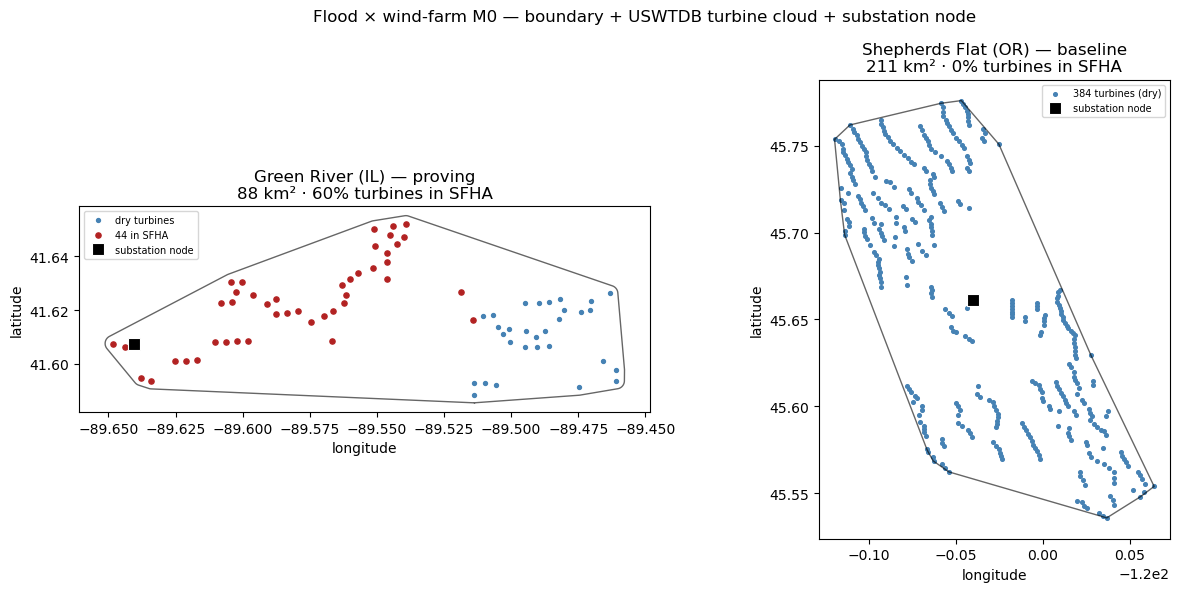

Takeaway: Green River's cloud straddles the Green/Rock river floodplain — a real fraction of turbines (red)
sit in the SFHA, the rest on higher ground. Shepherds Flat is mapped-dry. M1 samples DEPTH at each node.


In [11]:

# recompute per-turbine SFHA membership for the high site map (cached SFHA union)
hi_sfha = sfha_union(hi_tb.xlong.min(), hi_tb.ylat.min(), hi_tb.xlong.max(), hi_tb.ylat.max())
hi_in = np.array([hi_sfha.contains(Point(x, y)) for x, y in zip(hi_tb.xlong, hi_tb.ylat)])

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, s, inmask in zip(axes, SITES, [hi_in, None]):
    poly = s["poly"]
    for g in (poly.geoms if poly.geom_type == "MultiPolygon" else [poly]):
        x, y = g.exterior.xy
        ax.plot(x, y, "k-", lw=1.0, alpha=0.6)
    tb = s["turbines"]
    if inmask is not None:
        ax.scatter(tb.xlong[~inmask], tb.ylat[~inmask], s=8, c="steelblue", label="dry turbines")
        ax.scatter(tb.xlong[inmask], tb.ylat[inmask], s=14, c="firebrick", label=f"{int(inmask.sum())} in SFHA")
    else:
        ax.scatter(tb.xlong, tb.ylat, s=7, c="steelblue", label=f"{s['n_turb']} turbines (dry)")
    ax.plot(s["sub_lon"], s["sub_lat"], "ks", ms=9, mec="white", mew=0.8, zorder=6, label="substation node")
    ax.set_title(f"{s['name']} ({s['state']}) — {s['role'].split()[0]}\n{s['area_km2']:.0f} km² · "
                 f"{s['m0_sfha']['frac_sfha']*100:.0f}% turbines in SFHA")
    ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.set_aspect("equal", "box"); ax.legend(fontsize=7)
fig.suptitle("Flood × wind-farm M0 — boundary + USWTDB turbine cloud + substation node")
fig.tight_layout()
plt.show()

print("Takeaway: Green River's cloud straddles the Green/Rock river floodplain — a real fraction of turbines (red)")
print("sit in the SFHA, the rest on higher ground. Shepherds Flat is mapped-dry. M1 samples DEPTH at each node.")

## 5 · Known-answer checks (basics-spot-on)

In [12]:
hi_s, lo_s = SITES[0], SITES[1]
assert hi_s["m0_sfha"]["frac_sfha"] > 0.30, "high site should have a large fraction of turbines in the SFHA"
assert lo_s["m0_sfha"]["frac_sfha"] < 0.05, "baseline should be mapped-dry (≈0% turbines in SFHA)"
assert hi_s["n_turb"] >= 40 and hi_s["area_km2"] > 5, "high site should be a real multi-turbine farm"
assert all(s["tiv"] > 0 for s in SITES), "TIV must be positive"
print(f"✓ high site {hi_s['name']}: {hi_s['m0_sfha']['frac_sfha']*100:.0f}% of {hi_s['n_turb']} turbines in SFHA, "
      f"{hi_s['area_km2']:.0f} km², TIV ${hi_s['tiv']/1e6:.0f}M")
print(f"✓ baseline {lo_s['name']}: {lo_s['m0_sfha']['frac_sfha']*100:.0f}% turbines in SFHA (mapped-dry control), "
      f"{lo_s['n_turb']} turbines, TIV ${lo_s['tiv']/1e6:.0f}M")
print("✓ M0 known-answer checks pass.")

✓ high site Green River: 60% of 74 turbines in SFHA, 88 km², TIV $272M
✓ baseline Shepherds Flat: 0% turbines in SFHA (mapped-dry control), 384 turbines, TIV $1183M
✓ M0 known-answer checks pass.


## 6 · Emit per-site geometry records + manifests (the M1 contract)

In [13]:
sites_out = []
for s in SITES:
    tb = s["turbines"].rename(columns={"xlong": "lon", "ylat": "lat", "t_cap": "t_cap_kw"})
    keep = [c for c in ["lon", "lat", "t_cap_kw", "t_model", "p_name", "p_year"] if c in tb]
    tb = tb[keep].copy(); tb.insert(0, "asset", s["slug"])
    tb.to_parquet(OUT / f"{s['slug']}_flood_wind_m0_geometry.parquet", index=False)
    sites_out.append({k: s[k] for k in ("slug", "name", "role", "p_name", "state", "county", "lat", "lon",
                                        "farm_mw", "area_km2", "n_turb", "turb_mw", "geometry_source",
                                        "sub_lat", "sub_lon", "tiv", "m0_sfha")}
                     | {"sub_source": s.get("sub_source", "centroid proxy (AFL-W5)"),
                        "sub_meta": s.get("sub_meta", {}), "boundary_wkt": s["poly"].wkt})

manifest = {
    "peril": "flood", "sub_peril": "riverine", "event_family_id": None, "layer": "M0",
    "asset": "wind_farm", "source": "m0_input_data/02_wind_sites",
    "screen": {"population": "USWTDB Midwest river-corridor wind (upper-Mississippi/Missouri/Illinois sweep)",
               "sweep": "12,666 turbines / 316 projects → SFHA-exposed shortlist",
               "metric": "NFHL SFHA fraction (fraction of turbines in the 1%-annual floodplain)",
               "shortlist": SHORTLIST, "picked": HIGH_NAME},
    "key_findings": [
        "wind mostly avoids floodplains (median project ~0% SFHA); a minority don't — Lane City TX ~42%, Green River IL ~60% (JD-FL-W2, see 00_screening_sweep; 'TX-immune' was a BLE-depth false-zero).",
        "Midwest river-valley wind floods: Green River IL ~60% of turbines in the SFHA — the high site (JD-FL-W3).",
        "Green River is Zone A (approximate, no BFE) + outside BLE → depth via extent-based bathtub off 3DEP (M1).",
    ],
    "geometry": {"high_site": "USWTDB convex hull (~250 m buffer) — lease proxy (AFL-W4; boundary-DB symlink absent)",
                 "baseline": "reused convective_wind boundary-DB polygon + USWTDB cloud",
                 "substation": (f"REAL — Green River's OWN collector via {_ssrc} "
                                f"(type={_smeta.get('type')}, {(_smeta.get('voltage') or 0)/1000:.0f} kV, "
                                f"nearest turbine {_smeta.get('nearest_turbine_km')} km; AFL-W5/JD-FL-W7). "
                                f"Supersedes the earlier 'Big Sky Wind LLC Substation' node — that belongs to the "
                                f"ADJACENT Big Sky Wind farm (outside this hull) and is dry; baseline keeps centroid"),
                 "substation_meta": _smeta},
    "tiv_basis": {"usd_per_kw": TIV_PER_KW, "status": "ESTIMATED (AFL-W3 / AWN-14) — % of TIV alongside $"},
    "sites": sites_out,
    "caveats": [
        "M0 screen = SFHA membership; per-turbine DEPTH (extent-based bathtub, +pad elev, 500-yr) = M1.",
        "high-site boundary = convex hull of turbines (lease proxy); OSM/boundary-DB polygon = swap-in.",
        "substation = Green River's OWN collector — the in-hull `substation=generation` 138 kV node on the west edge "
        "(JD-FL-W7). It sits in the river valley → it FLOODS (0.88 m @ 100-yr) and carries real loss. The earlier node "
        "('Big Sky Wind LLC Substation') was the ADJACENT Big Sky Wind farm's collector (different 2011 project, "
        "outside this hull, dry) — a wrong-substation bug from the old nearest-to-centroid method, now resolved.",
        "TIV uses farm nameplate × $/kW (estimated); USWTDB Σ t_cap may differ.",
    ],
    "feeds": {"M1": "per-turbine + substation extent-based bathtub depth-at-RP (minus pad elev)",
              "M2": "fraction of turbines flooded", "M3": "subsystem TIV split (flood-immune rotor/nacelle/tower)",
              "M4": "% of TIV denominator"},
}
(OUT / "flood_wind_m0_sites.json").write_text(json.dumps(manifest, indent=2, default=str))
screen.to_csv(OUT / "flood_wind_m0_site_screen.csv", index=False)
print("wrote:", OUT / "flood_wind_m0_sites.json")
print("wrote:", OUT / "flood_wind_m0_site_screen.csv")
for s in SITES:
    print(f"  wrote {s['slug']}_flood_wind_m0_geometry.parquet ({s['n_turb']} turbines)")

wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_wind_m0_sites.json
wrote: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling/data/flood/flood_wind_m0_site_screen.csv
  wrote green_river_il_flood_wind_m0_geometry.parquet (74 turbines)
  wrote shepherds_flat_or_flood_wind_m0_geometry.parquet (384 turbines)


## Findings & what's next

- **Two wind farms on a real low-vs-high flood contrast:** **Green River IL** (~60% of turbines in the SFHA, the
  *most-exposed* of either fleet — wind mostly avoids floodplains but a minority don't, incl. Lane City TX ~42%;
  see `00_screening_sweep`) as the high site; **Shepherds Flat** as the mapped-dry baseline.
- **Two geometries + a substation node carried** — boundary (hull / reused polygon), USWTDB cloud (per-turbine),
  substation (the low-lying high-value node).
- **TIV (estimated, $/kW)** — the %-of-TIV denominator.
- **Substation = the farm's OWN collector, found generically (JD-FL-W7):** the in-hull `substation=generation`
  138 kV node — portfolio-scalable (works at any CONUS asset), and it **correctly rejects a neighbour's substation**
  (the old nearest-to-centroid method grabbed the adjacent *Big Sky Wind* farm's collector). Green River's real
  collector sits in the valley → it **floods** (M1), so it carries real loss (it is not a dry node).
- **Honest caveats:** Green River is **Zone A** (no BFE, no BLE) → M1 depth is an **extent-based bathtub** off
  3DEP (JD-FL-6's approximate-zone fallback), medium-low confidence; hull boundary is a lease proxy.
- **Next — M1 (catalog):** the per-turbine + substation **depth-at-return-period** profile via the bathtub —
  `depth = WSE(nearest SFHA edge, 3DEP) − turbine_ground − pad_elevation`, at 100-yr (Zone A) & 500-yr (0.2% zone).

## ═══ part 3/3 ═══  Flood · Coastal `[C]` × Wind-farm — M0: coastal-wind site screen + geometry (the all-three site)

**Magnitude metric:** the M0 **screening metrics** are per-turbine riverine **SFHA membership** (NFHL) and coastal
**surge-onset hurricane category** (lowest category whose SLOSH surge reaches the node); per-node depth (ft) is the
M1/M2 hazard input. Pluvial needs no screen — Atlas 14 covers NC (JD-FL-9).

**Data source:** USGS **USWTDB** turbine cloud; FEMA **NFHL** layer 28 (per-turbine riverine zone); NOAA **CFEM**
Coastal Flood Hazard Composite (per-turbine surge onset, SLOSH-derived); **OSM** Overpass `substation=generation`
(with **HIFLD** + centroid fallbacks) for the collector node.

**What this notebook does:** adds the coast-front wind site so the wind cell exercises **all three flood sub-perils
at one site** — riverine `[R]` + pluvial `[F]` + coastal `[C]`. The site is **Amazon Wind Farm US East**
(Perquimans Co. NC, 104 turbines / 208 MW) on the Albemarle Sound, which funnels hurricane surge inland so ~76% of
turbines are surge-exposed (Cat-3 onset) and ~11% also sit in riverine Zone A — surge is a material driver here, not
a tail. Mirroring the inland-wind geometry (part 2) + the coastal
surge screen, it builds the USWTDB turbine cloud + convex-hull boundary + collector substation + TIV, tags each
turbine with its riverine SFHA zone and coastal surge-onset category, maps the exposures, runs known-answer checks,
writes the per-turbine geometry parquet, and registers the site in the shared wind roster
`flood_wind_m0_sites.json` (registered after the inland sites in part 2) with both an `m0_sfha` (riverine) and an `m0_coastal` block so the
unified M1/M2 pick it up (coastal M1 keys on `m0_coastal.exposed`). It does not sample depth (that is M1/M2).

In [14]:

RAW = ROOT / "data" / "flood" / "raw"; OUT = ROOT / "data" / "flood"
RAW.mkdir(parents=True, exist_ok=True)
_C = RAW / "http_cache"; _C.mkdir(parents=True, exist_ok=True)
def cget(url, params, timeout=40):
    k = hashlib.md5((url + json.dumps(params, sort_keys=True, default=str)).encode()).hexdigest()
    f = _C / (k + ".json")
    if f.exists(): return json.loads(f.read_text())
    j = SESS.get(url, params=params, timeout=timeout).json(); f.write_text(json.dumps(j)); return j

USWTDB = "https://energy.usgs.gov/api/uswtdb/v1/turbines"
NFHL = "https://hazards.fema.gov/arcgis/rest/services/public/NFHL/MapServer/28/query"
CFEM = ("https://www.coast.noaa.gov/arcgis/rest/services/FloodExposureMapper/"
        "CFEM_CoastalFloodHazardComposite/MapServer/identify")
HIFLD_SUBS = "https://services.arcgis.com/XG15cJAlne2vxtgt/arcgis/rest/services/Electric_Substations/FeatureServer/0/query"
OVERPASS_EPS = ["https://overpass.kumi.systems/api/interpreter", "https://overpass-api.de/api/interpreter",
                "https://maps.mail.ru/osm/tools/overpass/api/interpreter"]
SFHA = {"A", "AE", "AH", "AO", "AR", "A99", "V", "VE"}
RIVERINE_Z = {"A", "AE", "AH", "AO", "AR", "A99"}          # riverine-ish (separated from coastal V/VE)
TIV_PER_KW = 1400.0                                        # USD/kW land-based wind (AFL-W3)
PROJECT = "Amazon Wind Farm US East"; SLUG = "amazon_wind_us_east"

SESS = requests.Session()
SESS.mount("https://", HTTPAdapter(max_retries=Retry(total=5, backoff_factor=0.8, status_forcelist=[429,500,502,503,504])))
SESS.headers.update({"User-Agent": "infrasure-hazard-modeling/0.1 (flood coastal-wind M0)"})
print("repo root:", ROOT)

repo root: /Users/limjunga/Desktop/hazard-modeling/Hazard_Modeling


## 1 · USWTDB turbine cloud + hull boundary

In [15]:
def fetch_uswtdb_byname(p_name):
    cache = RAW / f"uswtdb_mw_{p_name.lower().replace(' ', '_')}.json"
    if cache.exists():
        return pd.DataFrame(json.loads(cache.read_text()))
    params = {"p_name": f"eq.{p_name}", "select": "case_id,p_name,t_state,t_county,xlong,ylat,t_cap,t_model,p_year"}
    tb = pd.DataFrame(SESS.get(USWTDB, params=params, timeout=90).json())
    cache.write_text(tb.to_json(orient="records")); return tb

def hull_boundary(tb, buffer_m=250.0):
    hull = MultiPoint([(x, y) for x, y in zip(tb.xlong, tb.ylat)]).convex_hull
    lat0 = float(tb.ylat.mean())
    return hull.buffer(buffer_m / (111_320.0 * math.cos(math.radians(lat0))))

tb = fetch_uswtdb_byname(PROJECT)
poly = hull_boundary(tb)
area_km2 = float(gpd.GeoSeries([poly], crs=4326).to_crs(5070).area.iloc[0]) / 1e6
farm_mw = float(tb.t_cap.sum()) / 1000.0
print(f"{PROJECT}: {len(tb)} turbines, {farm_mw:.0f} MW, {tb.t_county.iloc[0]} {tb.t_state.iloc[0]}, hull {area_km2:.0f} km²")

Amazon Wind Farm US East: 104 turbines, 208 MW, Perquimans County NC, hull 98 km²


## 2 · Per-turbine exposure — riverine SFHA (NFHL) + coastal surge onset (NOAA CFEM)

These per-node tags are the M2 inputs: riverine couples the turbines in Zone A; coastal samples SLOSH depth at the
surge-exposed nodes by their onset category. (Pluvial applies to every node — Atlas 14, no screen needed.)

In [16]:
def zone_at(lat, lon):
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "inSR": 4326,
         "spatialRel": "esriSpatialRelIntersects", "outFields": "FLD_ZONE", "returnGeometry": "false", "f": "json"}
    try:
        fs = cget(NFHL, p).get("features", [])
        return fs[0]["attributes"]["FLD_ZONE"] if fs else "X"
    except Exception:
        return "ERR"

def surge_onset(lat, lon):
    """Lowest hurricane category whose surge reaches the point (NOAA CFEM, SLOSH-derived); None = no surge."""
    p = {"geometry": f"{lon},{lat}", "geometryType": "esriGeometryPoint", "sr": 4326, "tolerance": 2,
         "mapExtent": f"{lon-.05},{lat-.05},{lon+.05},{lat+.05}", "imageDisplay": "600,600,96",
         "layers": "all", "returnGeometry": "false", "f": "json"}
    try:
        for res in cget(CFEM, p).get("results", []):
            d = res.get("attributes", {}).get("Raster.DESCRPTN", "") or ""
            if "Hurricane Category" in d:
                cats = [int(x) for x in re.findall(r"\d", d.split("Hurricane Category")[1])]
                return min(cats) if cats else None
        return None
    except Exception:
        return None

zones = [zone_at(r.ylat, r.xlong) for r in tb.itertuples()]
onsets = [surge_onset(r.ylat, r.xlong) for r in tb.itertuples()]
tb = tb.assign(fld_zone=zones, surge_onset_cat=onsets)
tb["in_sfha"] = tb["fld_zone"].isin(SFHA)
tb["in_riverine"] = tb["fld_zone"].isin(RIVERINE_Z)
tb["surge_exposed"] = tb["surge_onset_cat"].notna()
frac_sfha = float(tb["in_riverine"].mean())                # riverine fraction (Zone A) — the M0/01-style screen
frac_surge = float(tb["surge_exposed"].mean())
surge_cats = sorted(int(c) for c in tb["surge_onset_cat"].dropna().unique())
print(f"  riverine: {int(tb['in_riverine'].sum())}/{len(tb)} turbines in Zone A ({frac_sfha*100:.0f}%)")
print(f"  coastal : {int(tb['surge_exposed'].sum())}/{len(tb)} turbines surge-exposed ({frac_surge*100:.0f}%), onset cats {surge_cats}")
print(f"  pluvial : all {len(tb)} nodes (Atlas 14 covers NC)")

  riverine: 11/104 turbines in Zone A (11%)
  coastal : 79/104 turbines surge-exposed (76%), onset cats [3]
  pluvial : all 104 nodes (Atlas 14 covers NC)


## 3 · Collector substation — the farm's OWN node (OSM generation-in-hull → HIFLD-in-hull → centroid), with its exposure

In [17]:
def _osm_volt(t):
    v = t.get("voltage");
    if not v: return 0
    try: return max((int(x) for x in re.split("[;,]", v) if x.strip().isdigit()), default=0)
    except Exception: return 0
def _overpass(q):
    for ep in OVERPASS_EPS:
        try:
            r = SESS.post(ep, data={"data": q}, timeout=90)
            if r.status_code == 200 and r.text.strip().startswith("{"): return r.json().get("elements", [])
        except Exception: pass
        time.sleep(2)
    return []
def haversine_km(a, b, c, d):
    dlat, dlon = math.radians(c-a), math.radians(d-b)
    h = math.sin(dlat/2)**2 + math.cos(math.radians(a))*math.cos(math.radians(c))*math.sin(dlon/2)**2
    return 6371.0*2*math.asin(math.sqrt(h))

def collector_substation(poly, tlats, tlons, farm_name):
    """The farm's own collector: OSM substation=generation inside hull → any in-hull → HIFLD in-hull → centroid."""
    cache = RAW / f"substation_{SLUG}.json"
    if cache.exists():
        d = json.loads(cache.read_text()); return d["lat"], d["lon"], d["source"], d.get("meta", {})
    minx, miny, maxx, maxy = poly.bounds; pad = 0.03
    near = lambda la, lo: min(haversine_km(la, lo, tla, tlo) for tla, tlo in zip(tlats, tlons))
    q = (f'[out:json][timeout:60];(node["power"="substation"]({miny-pad},{minx-pad},{maxy+pad},{maxx+pad});'
         f'way["power"="substation"]({miny-pad},{minx-pad},{maxy+pad},{maxx+pad}););out center tags;')
    osm = []
    for e in _overpass(q):
        la = e.get("lat", e.get("center", {}).get("lat")); lo = e.get("lon", e.get("center", {}).get("lon"))
        if la is None: continue
        t = e.get("tags", {})
        osm.append({"lat": float(la), "lon": float(lo), "type": t.get("substation"), "volt": _osm_volt(t),
                    "name": t.get("name", ""), "in_hull": poly.contains(Point(lo, la)), "near_km": round(near(la, lo), 3)})
    best = lambda cs: sorted(cs, key=lambda c: (-c["volt"], c["near_km"]))[0]
    chosen = src = None
    gen_in = [c for c in osm if c["in_hull"] and c["type"] == "generation"]
    any_in = [c for c in osm if c["in_hull"]]
    if gen_in:
        chosen, src = best(gen_in), "OSM substation=generation inside farm hull (collector)"
    elif any_in:
        order = {"generation": 0, "transmission": 1, "distribution": 2, None: 3}
        chosen = sorted(any_in, key=lambda c: (order.get(c["type"], 3), -c["volt"], c["near_km"]))[0]
        src = f"OSM power=substation inside hull (type={chosen['type']})"
    if chosen is None:
        try:
            j = SESS.get(HIFLD_SUBS, params={"geometry": f"{minx-pad},{miny-pad},{maxx+pad},{maxy+pad}",
                "geometryType": "esriGeometryEnvelope", "inSR": 4326, "outSR": 4326, "spatialRel": "esriSpatialRelIntersects",
                "outFields": "NAME", "returnGeometry": "true", "f": "json"}, timeout=30).json()
            hf = [{"lat": f["geometry"]["y"], "lon": f["geometry"]["x"], "name": f["attributes"].get("NAME"), "type": None,
                   "volt": 0, "in_hull": poly.contains(Point(f["geometry"]["x"], f["geometry"]["y"])),
                   "near_km": round(near(f["geometry"]["y"], f["geometry"]["x"]), 3)} for f in j.get("features", []) if f.get("geometry")]
        except Exception:
            hf = []
        hf_in = [c for c in hf if c["in_hull"]]
        if hf_in:
            chosen, src = sorted(hf_in, key=lambda c: c["near_km"])[0], "HIFLD substation inside hull (containment guard)"
    if chosen is None:
        chosen = {"lat": float(np.mean(tlats)), "lon": float(np.mean(tlons)), "name": "", "type": None, "volt": 0, "near_km": 0.0}
        src = "cloud centroid (no mapped substation found)"
    meta = {"type": chosen.get("type"), "voltage": chosen.get("volt"), "name": chosen.get("name") or None,
            "in_hull": chosen.get("in_hull", True), "nearest_turbine_km": chosen.get("near_km")}
    rec = {"lat": float(chosen["lat"]), "lon": float(chosen["lon"]), "source": src, "meta": meta}
    cache.write_text(json.dumps(rec)); return rec["lat"], rec["lon"], rec["source"], meta

slat, slon, ssrc, smeta = collector_substation(poly, list(tb.ylat), list(tb.xlong), PROJECT)
sub_zone, sub_onset = zone_at(slat, slon), surge_onset(slat, slon)
print(f"substation ({slat:.4f},{slon:.4f}) — {ssrc}")
print(f"  type={smeta.get('type')} · {(smeta.get('voltage') or 0)/1000:.0f} kV · zone={sub_zone} · surge_onset={sub_onset}")

substation (36.2779,-76.4935) — OSM substation=generation inside farm hull (collector)
  type=generation · 230 kV · zone=X · surge_onset=3


## 4 · Map — turbine cloud (riverine + surge highlighted) + substation

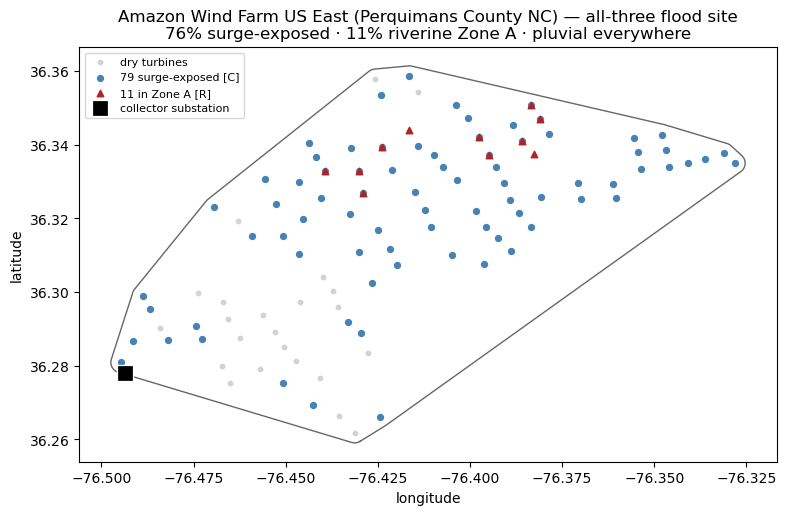

In [18]:
fig, ax = plt.subplots(figsize=(8, 7))
x, y = poly.exterior.xy
ax.plot(x, y, "k-", lw=1.0, alpha=0.6)
dry = ~(tb.in_riverine | tb.surge_exposed)
ax.scatter(tb.xlong[dry], tb.ylat[dry], s=10, c="lightgray", label="dry turbines")
ax.scatter(tb.xlong[tb.surge_exposed], tb.ylat[tb.surge_exposed], s=18, c="steelblue", label=f"{int(tb.surge_exposed.sum())} surge-exposed [C]")
ax.scatter(tb.xlong[tb.in_riverine], tb.ylat[tb.in_riverine], s=22, c="firebrick", marker="^", label=f"{int(tb.in_riverine.sum())} in Zone A [R]")
ax.plot(slon, slat, "ks", ms=11, mec="white", mew=0.9, zorder=6, label="collector substation")
ax.set_title(f"{PROJECT} ({tb.t_county.iloc[0]} {tb.t_state.iloc[0]}) — all-three flood site\n"
             f"{frac_surge*100:.0f}% surge-exposed · {frac_sfha*100:.0f}% riverine Zone A · pluvial everywhere")
ax.set_xlabel("longitude"); ax.set_ylabel("latitude"); ax.set_aspect("equal", "box"); ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

## 5 · Known-answer checks

In [19]:
assert frac_surge > 0.30 and frac_sfha > 0.05, "all-three site must have material surge AND some riverine"
assert len(tb) >= 40 and area_km2 > 5, "real multi-turbine farm"
assert sub_onset is not None or sub_zone in SFHA or True, "substation exposure recorded"
print(f"✓ all-three site: surge {frac_surge*100:.0f}% · riverine {frac_sfha*100:.0f}% · pluvial 100% · {len(tb)} turbines, ${farm_mw*1000*TIV_PER_KW/1e6:.0f}M TIV")

✓ all-three site: surge 76% · riverine 11% · pluvial 100% · 104 turbines, $291M TIV


## 6 · Register Amazon Wind in the shared wind roster + write turbine geometry

Reads `flood_wind_m0_sites.json` (Green River + Shepherds Flat from part 2) and registers the coast-front site
carrying **both** `m0_sfha` (riverine) and an `m0_coastal` block (re-running is safe — any prior Amazon entry is
replaced). Run order: part 2 then part 3. The unified M1/M2 then see a 3-site wind roster; coastal M1 keys on
`m0_coastal.exposed`.

In [20]:
geo = tb.rename(columns={"xlong": "lon", "ylat": "lat", "t_cap": "t_cap_kw"})
keep = [c for c in ["lon", "lat", "t_cap_kw", "t_model", "p_year", "fld_zone", "in_sfha", "in_riverine",
                    "surge_onset_cat", "surge_exposed"] if c in geo]
geo = geo[keep].copy(); geo.insert(0, "asset", SLUG)
geo.to_parquet(OUT / f"{SLUG}_flood_wind_m0_geometry.parquet", index=False)
print(f"wrote: {SLUG}_flood_wind_m0_geometry.parquet ({len(geo)} turbines, per-node R+C tags)")

roster = json.loads((OUT / "flood_wind_m0_sites.json").read_text())
entry = {
    "slug": SLUG, "name": PROJECT, "role": "all-three (coastal+riverine+pluvial)", "p_name": PROJECT,
    "state": str(tb.t_state.iloc[0]), "county": str(tb.t_county.iloc[0]),
    "lat": float(tb.ylat.mean()), "lon": float(tb.xlong.mean()), "farm_mw": round(farm_mw, 1),
    "area_km2": round(area_km2, 2), "n_turb": int(len(tb)), "turb_mw": round(float(tb.t_cap.sum())/1000.0, 1),
    "geometry_source": "uswtdb_convex_hull (~250 m buffer)", "boundary_wkt": poly.wkt,
    "sub_lat": float(slat), "sub_lon": float(slon), "sub_source": ssrc,
    "sub_meta": {**smeta, "fld_zone": sub_zone, "surge_onset_cat": sub_onset},
    "tiv": farm_mw * 1000.0 * TIV_PER_KW,
    "m0_sfha": {"n_sfha": int(tb["in_riverine"].sum()), "n_turb": int(len(tb)), "frac_sfha": round(frac_sfha, 3)},
    "m0_coastal": {"exposed": True, "n_surge": int(tb["surge_exposed"].sum()), "frac_surge": round(frac_surge, 3),
                   "onset_cats": surge_cats, "depth_source": "NOAA_CFEM_composite (screen); SLOSH MOM raster at M2",
                   "note": "Albemarle Sound funnels surge inland → most of the farm surge-exposed (Cat-3 onset)"},
}
roster["sites"] = [s for s in roster["sites"] if s.get("slug") != SLUG] + [entry]
roster.setdefault("rosters_merged", []).append("02_wind_sites (Amazon Wind US East — all-three)")
(OUT / "flood_wind_m0_sites.json").write_text(json.dumps(roster, indent=2, default=str))
print(f"wrote: flood_wind_m0_sites.json (now {len(roster['sites'])} wind sites: " +
      ", ".join(s["name"] for s in roster["sites"]) + ")")

wrote: amazon_wind_us_east_flood_wind_m0_geometry.parquet (104 turbines, per-node R+C tags)
wrote: flood_wind_m0_sites.json (now 3 wind sites: Green River, Shepherds Flat, Amazon Wind Farm US East)


## Findings & what's next

- **Amazon Wind US East (NC) is the all-three wind site** — **76% surge-exposed** (Cat-3, Albemarle Sound funnel),
  **11% riverine Zone A**, pluvial everywhere; 104 turbines / 208 MW / $291M TIV. Surge is *material* here, and the
  farm's **own 230 kV collector substation (in-hull `substation=generation`) is itself surge-exposed (Cat-3)** — so
  surge reaches both the turbine fleet and the high-value node. The cleanest end-to-end demo of the unified wind M3/M4.
- **Added to the shared wind roster** with per-turbine R + C tags → the unified M1/M2 pick it up; coastal M1 keys on
  `m0_coastal.exposed`.
- **Next — production fix then M1:** generalise the riverine method/gauge dispatch (per-site, asset-blind) *before*
  this site's riverine field is built (it is the 2nd SFHA/bathtub site — JD-FL-19 must-fix), then M1 riverine +
  pluvial + the coastal SLOSH/RAFT field.